In [1]:
import jaxquantum as jqt
import jaxquantum.devices as jqtd
import jax.numpy as jnp

import matplotlib.pyplot as plt

from jax import jit


# Simple Two-level System

## Time Rabi Chevron

In [2]:
fq = 5 # [GHz]
H0 = 2 * jnp.pi * fq * jqt.sigmaz() / 2

g_d = 2 * jnp.pi * 0.01 # [GHz]

omega_01 = 2 * jnp.pi * fq
omegas = omega_01 + 2 * jnp.pi * jnp.linspace(-0.01, 0.01, 21) 

def Ht(t):
    return H0 + g_d * jqt.sigmax() * jnp.cos(omegas * t)


g_ket = jqt.basis(2, 0)
e_ket = jqt.basis(2, 1)

omegas = omega_01 + 2 * jnp.pi * jnp.linspace(-0.01, 0.01, 21) 
ts = jnp.linspace(0, 100, 101)


results = jqt.sesolve(
    Ht,
    g_ket,
    ts
)

g = g_ket
e = e_ket
sz = g @ g.dag() - e @ e.dag()
overlaps = jqt.overlap(results, sz)

100% |██████████| [00:00<00:00, 212.87%/s]


Text(0.5, 1.0, '$⟨σ_z⟩$')

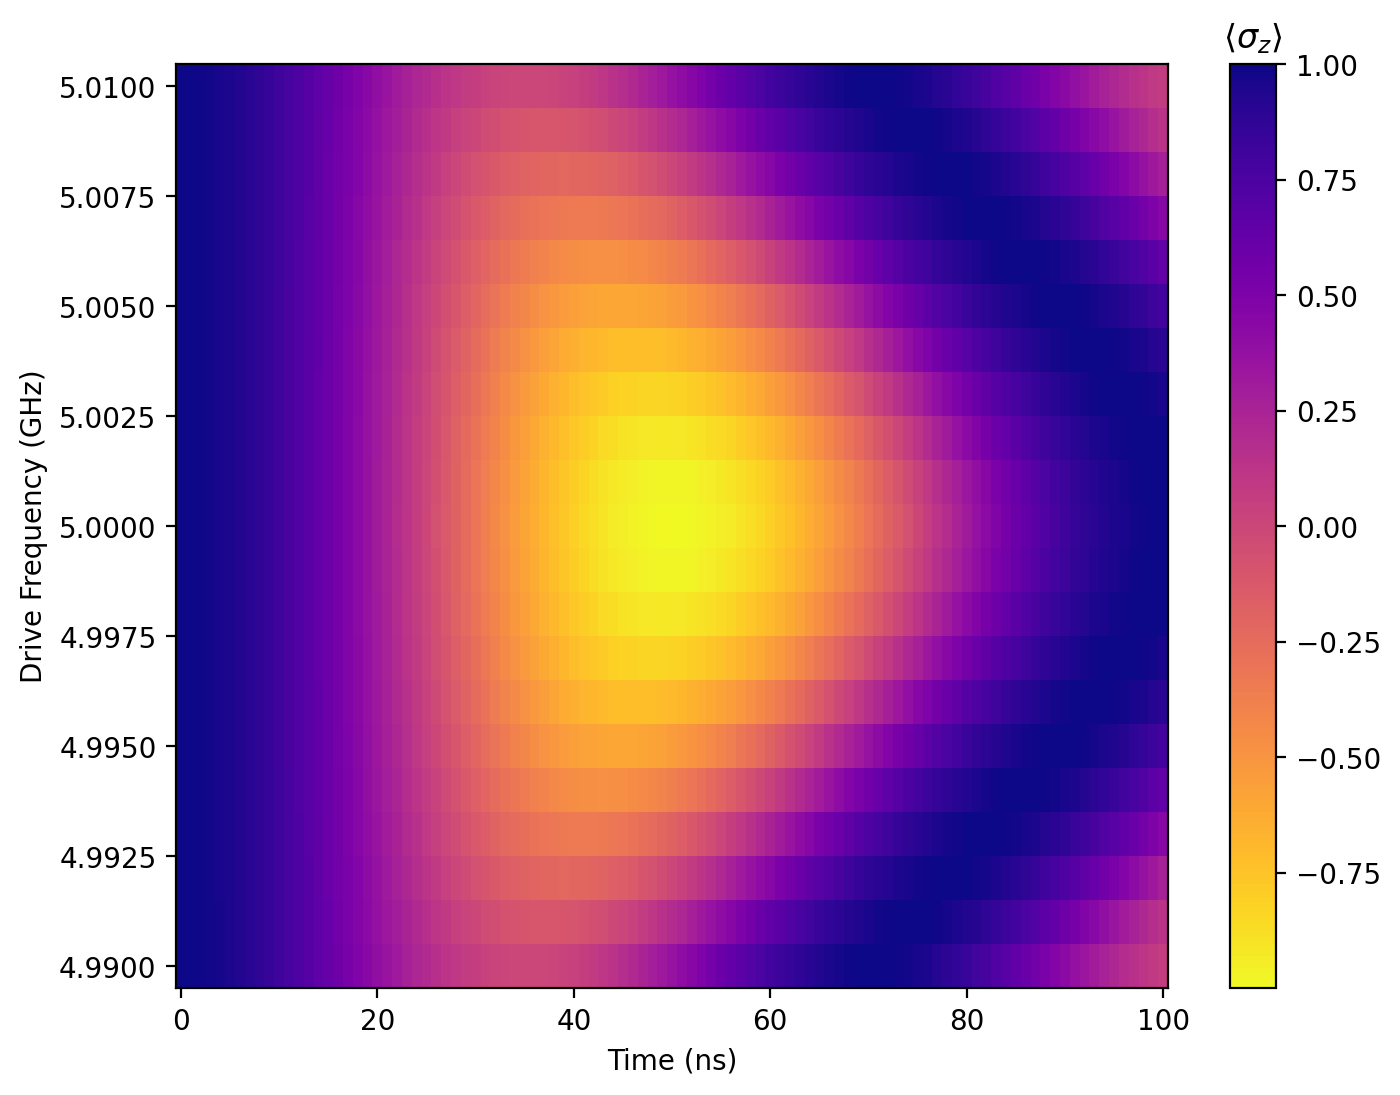

In [3]:
fig, ax = plt.subplots(1,1, figsize=(8,6), dpi=200)

im = ax.pcolormesh(ts, omegas / (2 * jnp.pi), overlaps.real.T, cmap="plasma_r")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Drive Frequency (GHz)")
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_title("$⟨σ_z⟩$")

## Cost Function

In [4]:
@jit
def calc_metric(pulse_freq_GHz, pulse_time_ns, pulse_amp_factor):
    # want to minimize this metric to be as close to -1 as possible (which corresponds to a perfect pi pulse g->e)
    fq = 5 # [GHz]
    H0 = 2 * jnp.pi * fq * jqt.sigmaz() / 2

    g_d = 2 * jnp.pi * 0.01 # [GHz]


    def Ht(t):
        # uses square envelope (modulated at pulse_freq_GHz) for now.. this envelope can also be optimized over.
        return H0 + pulse_amp_factor * g_d * jqt.sigmax() * jnp.cos(2 * jnp.pi * pulse_freq_GHz * t)


    g_ket = jqt.basis(2, 0)
    e_ket = jqt.basis(2, 1)

    omegas = omega_01 + 2 * jnp.pi * jnp.linspace(-0.01, 0.01, 21) 
    ts = jnp.linspace(0, pulse_time_ns, 2)

    solver_options = jqt.SolverOptions.create(
        progress_meter = False
    )

    results = jqt.sesolve(
        Ht,
        g_ket,
        ts,
        solver_options=solver_options
    )

    g = g_ket
    e = e_ket
    sz = g @ g.dag() - e @ e.dag()
    overlaps = jqt.overlap(results, sz)

    return overlaps[-1].real

In [5]:
calc_metric(5.0, 50.0, 1.0)

Array(-0.99998882, dtype=float64)

# Tunable Transmon

## Time Rabi Chevron on Tunable Transmon

In [6]:
Ec_q = 0.3
Ej_q = 15
phi_ext = 0.0

N = 4

qubit = jqtd.TunableTransmon.create(
    N,
    {"Ec": Ec_q, "Ej1": Ej_q, "Ej2": Ej_q, "phi_ext": phi_ext},
    basis=jqtd.BasisTypes.charge,
    hamiltonian=jqtd.HamiltonianTypes.full,
    N_pre_diag=23,
)

H_full = qubit.get_H()
Es = qubit.eig_systems["vals"]
n_op = qubit.ops["n"]
omega_01 = 2 * jnp.pi * (Es[1] - Es[0])

g_ket = jqt.basis(N, 0)
e_ket = jqt.basis(N, 1)

In [7]:
omegas = omega_01 + 2 * jnp.pi * jnp.linspace(-0.01, 0.01, 21) 
ts = jnp.linspace(0, 100, 101)

g_d = 2 * jnp.pi * 0.010

def Ht(t):
    return 2 * jnp.pi * H_full + g_d * n_op * jnp.cos(omegas * t)

results = jqt.sesolve(
    Ht,
    g_ket,
    ts
)

g = g_ket
e = e_ket
sz = g @ g.dag() - e @ e.dag()
overlaps = jqt.overlap(results, sz)

100% |██████████| [00:04<00:00, 21.14%/s]


Text(0.5, 1.0, '$⟨σ_z⟩$')

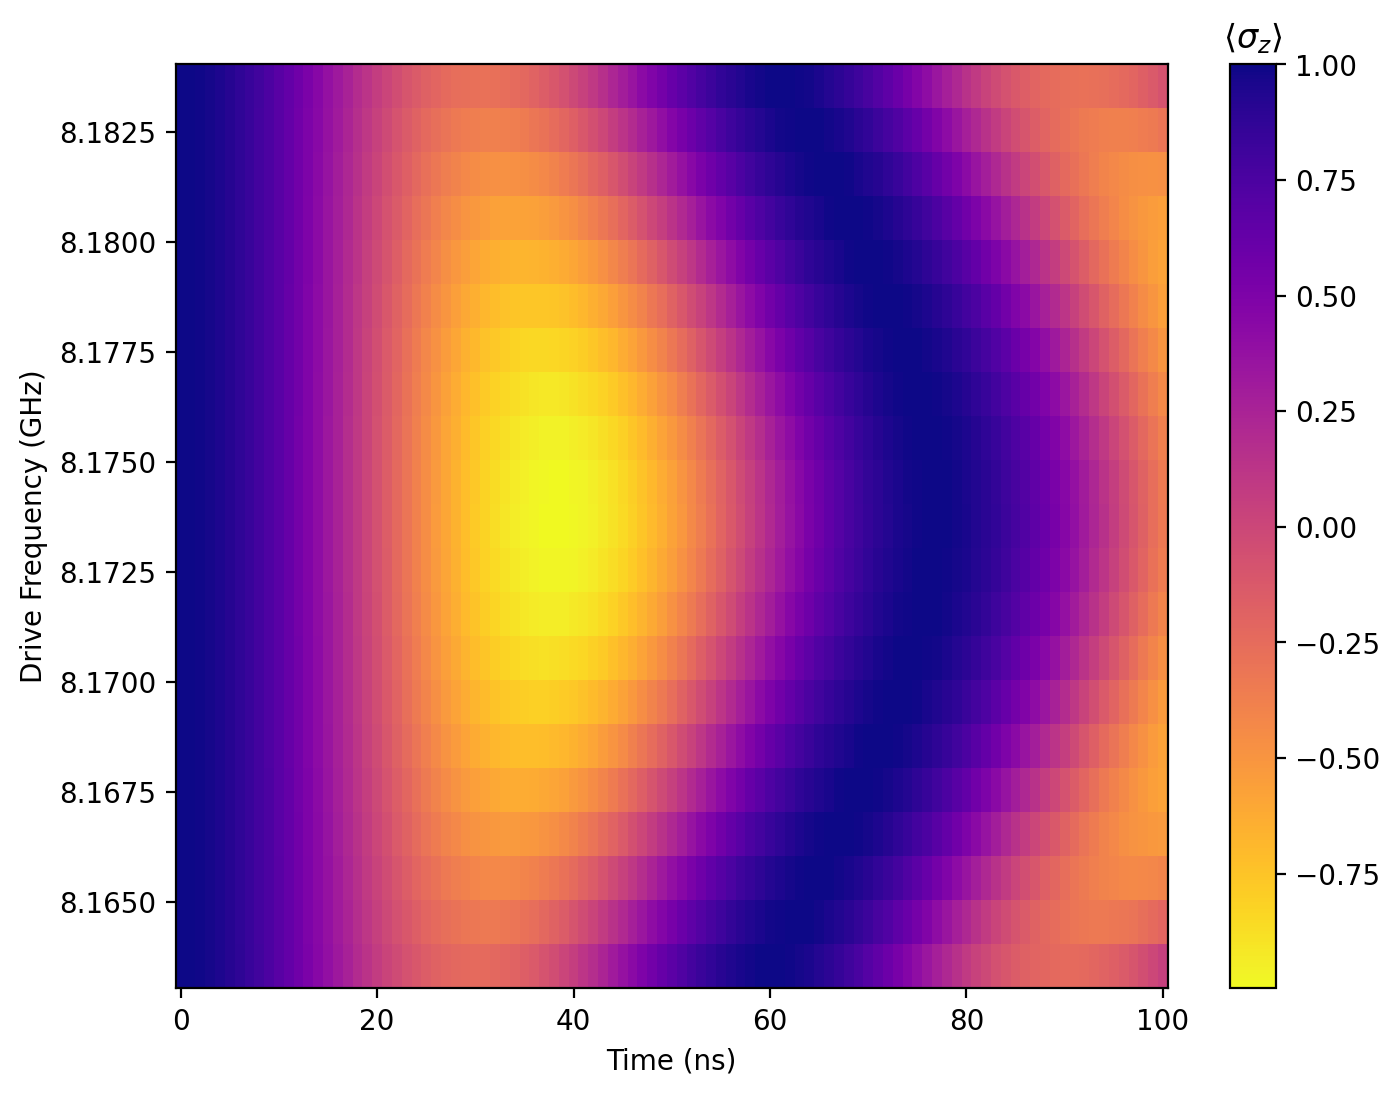

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8,6), dpi=200)

im = ax.pcolormesh(ts, omegas / (2 * jnp.pi), overlaps.real.T, cmap="plasma_r")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Drive Frequency (GHz)")
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_title("$⟨σ_z⟩$")

## Cost Function

In [9]:
def setup_qubit():
    Ec_q = 0.3
    Ej_q = 15
    phi_ext = 0.0

    N = 4

    qubit = jqtd.TunableTransmon.create(
        N,
        {"Ec": Ec_q, "Ej1": Ej_q, "Ej2": Ej_q, "phi_ext": phi_ext},
        basis=jqtd.BasisTypes.charge,
        hamiltonian=jqtd.HamiltonianTypes.full,
        N_pre_diag=23,
    )

    H_full = qubit.get_H()
    Es = qubit.eig_systems["vals"]
    n_op = qubit.ops["n"]
    f_01 = (Es[1] - Es[0])

    g_ket = jqt.basis(N, 0)
    e_ket = jqt.basis(N, 1)

    system = {
        "H_full": H_full,
        "n_op": n_op,
        "f_01": f_01,
        "g_ket": g_ket,
        "e_ket": e_ket,
        "ts": jnp.linspace(0, 100, 101),
        "g_d": 2 * jnp.pi * 0.010
    }

    return qubit, system

In [10]:
qubit, system = setup_qubit()

@jit
def calc_metric(pulse_freq_GHz, pulse_time_ns, pulse_amp_factor):
    # minimize this metric so that g->e
    
    def Ht(t):
        return 2 * jnp.pi * system["H_full"] + pulse_amp_factor * system["g_d"] * system["n_op"] * jnp.cos(2*jnp.pi*pulse_freq_GHz * t)

    ts = jnp.linspace(0, pulse_time_ns, 2)

    solver_options = jqt.SolverOptions.create(
        progress_meter = False
    )

    results = jqt.sesolve(
        Ht,
        system["g_ket"],
        ts,
        # saveat_tlist=-1 # only saves the final state,
        solver_options=solver_options
    )

    g = system["g_ket"]
    e = system["e_ket"]
    sz = g @ g.dag() - e @ e.dag()
    overlaps = jqt.overlap(results, sz) # <sz> should be -1 for the excited state

    return overlaps[-1].real

In [11]:
f_01_GHz = system["f_01"]
pulse_time_ns = 40.0

calc_metric(f_01_GHz, pulse_time_ns, 0.5), calc_metric(f_01_GHz, pulse_time_ns, 1.0)

(Array(-0.06829089, dtype=float64), Array(-0.98924275, dtype=float64))